In [1]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves, plot_multiple_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


🔄 Chargement des données:   0%|          | 0/50 [00:00<?, ?exp/s]

🔄 Chargement des données: 100%|██████████| 50/50 [00:03<00:00, 12.62exp/s]


🔔 Starting Regression/ResNet_Folds_data_augm fold 1

             DOPPLER DATASET INITIALIZATION SUMMARY
→ Active Antenna 2         : False
→ Active Phase             : False
→ Use previous frames      : False
→ Fold number              : 1
→ Total experiments        : 50
→ Dataset sizes (samples) :
   • Train set             : 40000
   • Validation set        : 5000
   • Test set              : 5000
→ Final selected dataset   : 50000 samples


                 NETWORK INITIALIZATION SUMMARY
→ Device                  : mps
→ Results path            : results/Regression/ResNet_Folds_data_augm/fold1
→ Epochs                  : 15
→ Learning rate           : 0.0001
→ Batch size              : 16
→ Prediction type         : regression
→ Data augmentation       : True

🎨 Visualizing Data Augmentation (original vs augmented)


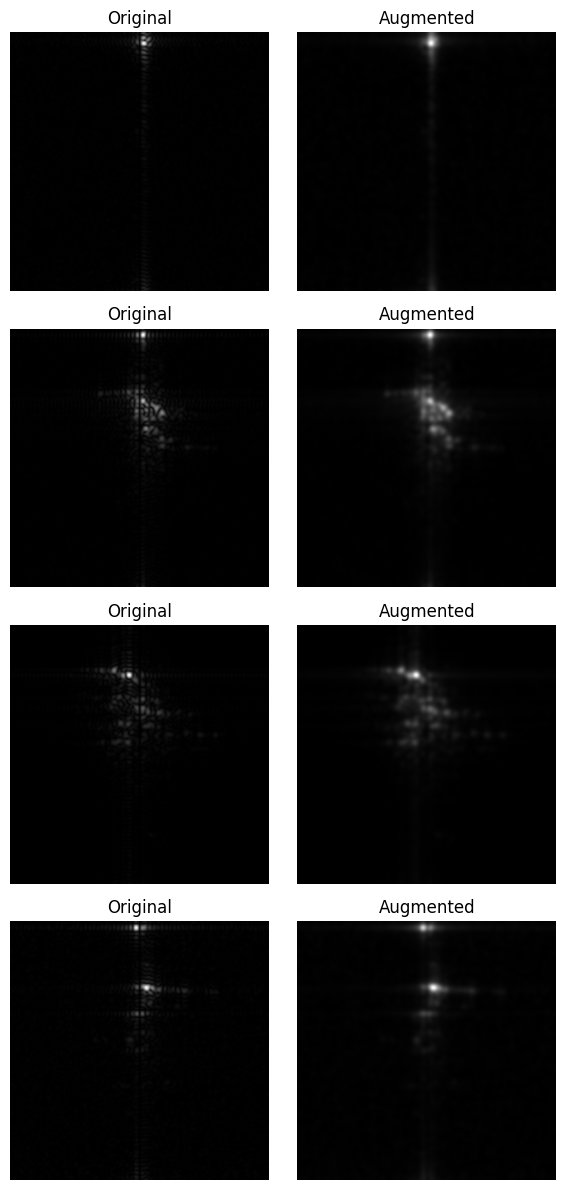

In [2]:
l_exp = [f"Regression/ResNet_Folds_data_augm"]
folds = list(range(1, 2))
data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    for fold in folds :
        print(f"🔔 Starting {exp} fold {fold}")
        stream = open(f"exp_list/{exp}.yaml", 'r')
        param  = yaml.safe_load(stream)
        param["TRAINING"]["DEVICE"] = 'mps'
        param["DATASET"]["FOLD_NUMBER"] = fold

        resultsPath = os.path.join("results", exp, f"fold{fold}")

        # Create the directory
        if not os.path.exists(resultsPath):
            os.makedirs(resultsPath)

        myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

        myNetwork.visualize_data_augmentation()

        # Train the network
        #train_losses, val_losses =  myNetwork.train(fold)

        # Test the network
        #myNetwork.loadWeight()
        #myNetwork.test(fold)




In [14]:
all_train_losses = []
all_val_losses = []

exp = "Regression/ResNet_Folds_OneCycleLR"
resultsPath = os.path.join("results", exp)
folds = [2,3,5,8] #list(range(1, 9))

for fold in folds :
    train_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "train_losses.npy"))
    val_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "val_losses.npy"))
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)

plot_multiple_learning_curves(all_train_losses, all_val_losses, resultsPath)


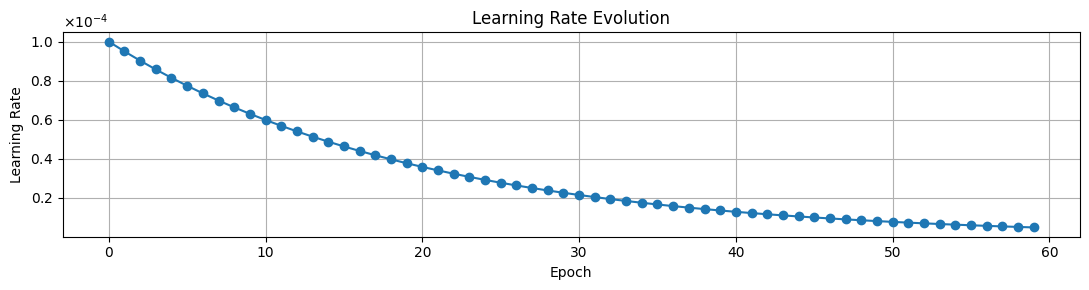

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# Paramètres donnés
initial_lr = 0.0001
gamma = 0.95
epochs = 60

# Calcul du LR pour chaque epoch
lr_values = [initial_lr * (gamma ** epoch) for epoch in range(epochs)]

# Tracé
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Learning Rate Evolution")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
# Activation de la notation scientifique pour l'axe y
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.show()


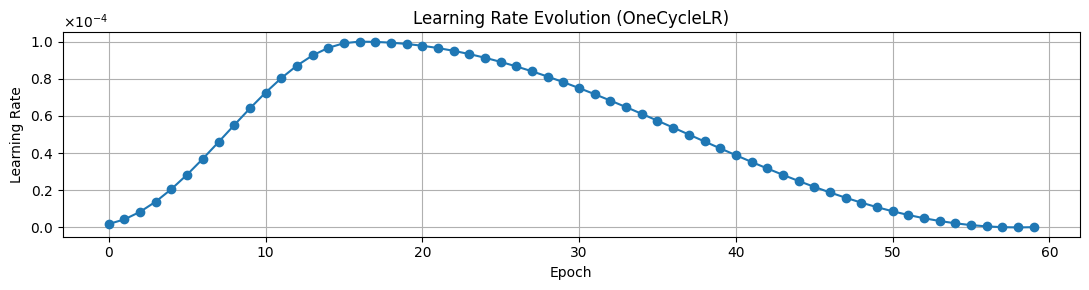

In [12]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn as nn

# Paramètres
epochs = 60
lr_start = 1e-6
max_lr = 1e-4
steps_per_epoch = 1  # pour visualisation simple : 1 update par epoch
total_steps = steps_per_epoch * epochs

# Dummy model
model = nn.Linear(10, 1)
optimizer = Adam(model.parameters(), lr=lr_start)

# Scheduler OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr=max_lr,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    anneal_strategy="cos",
    div_factor=max_lr / lr_start  # pour respecter le lr de départ donné
)

# Simuler les updates
lr_values = []
for step in range(total_steps):
    scheduler.step()
    lr_values.append(optimizer.param_groups[0]['lr'])

# Tracer
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Learning Rate Evolution (OneCycleLR)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.show()


[0.20321103 0.09796093 0.06623464 0.04499499 0.03380588 0.02732223
 0.02234211 0.0198419  0.01693863 0.01554974 0.01341462 0.01218816
 0.01102781 0.00987346 0.0091803  0.00865232 0.00789372 0.00732938
 0.00719508 0.00636973 0.00618473 0.00598575 0.00564355 0.00516806
 0.00485653 0.00470602 0.00455057 0.00436938 0.00415826 0.00394643]
[0.12399735 0.11112183 0.08851593 0.08507702 0.08418153 0.08420281
 0.10226381 0.07553372 0.11757585 0.10635803 0.08691121 0.08477256
 0.07138798 0.10249646 0.09462021 0.09022721 0.07083029 0.12818368
 0.06875364 0.06429093 0.06587857 0.06527986 0.07012084 0.06424863
 0.06846183 0.06492496 0.06434959 0.06602878 0.0634154  0.06265724]


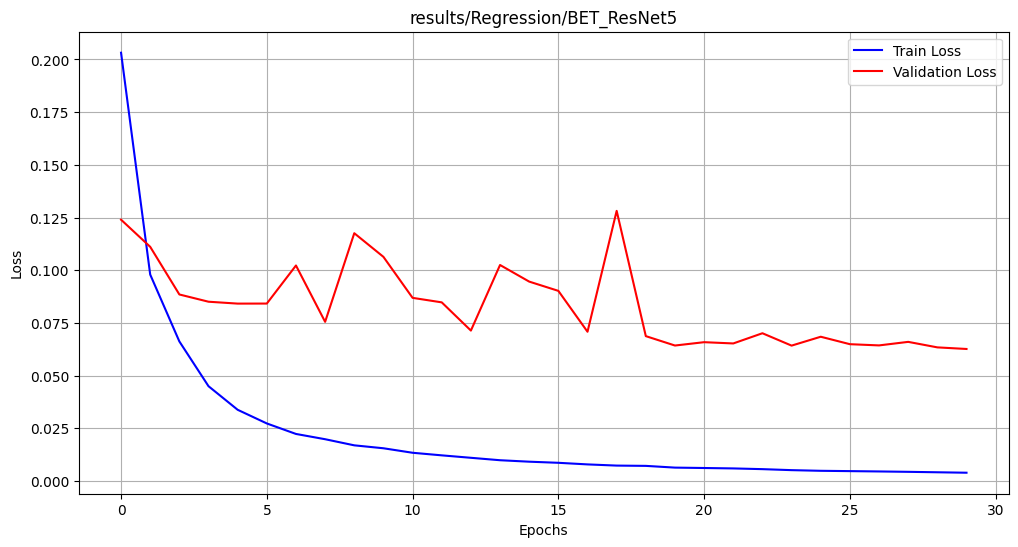

In [ ]:
exp = "Regression/BET_ResNet5"
resultsPath = os.path.join("results", exp)

# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)
plot_learning_curves(train_losses, val_losses, resultsPath)